## Notch experiments: do not run, outdated methods 

In [6]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_reinoud import Bridge

import numpy as np
import matplotlib.pyplot as plt

In [7]:


# Initiation: load beam library, select beams for experiment and set parameters.
library_name = 'notch8_single'
library = open_beam_library(library_name + '.json')
selection = ['A1', 'B1', 'C1']
lib = sublibrary(selection, library)

R_ref = 50 # Ohm
U_in = 10 # V

f_arr = np.logspace(2, 5, 1000)
w_arr = 2*np.pi*f_arr

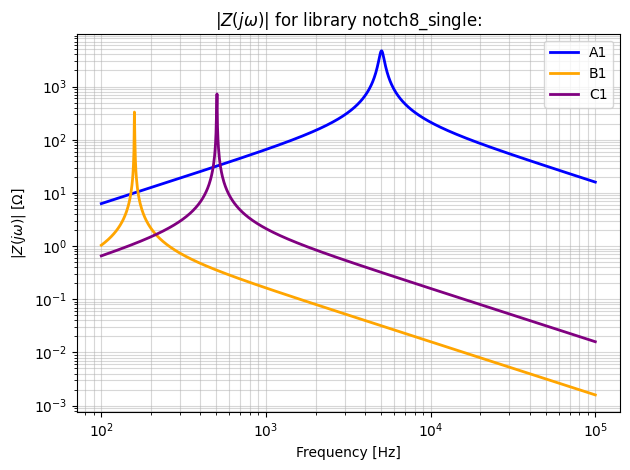

In [8]:
fig, ax = plt.subplots()
colors = ['blue', 'orange', 'purple']

for key, color in zip(list(lib.keys()), colors):
    
    y = lib[key].admittance(w_arr)
    z_abs = 1 / np.abs(y)

    ax.loglog(f_arr, z_abs, color=color, label=key, linewidth=2)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()



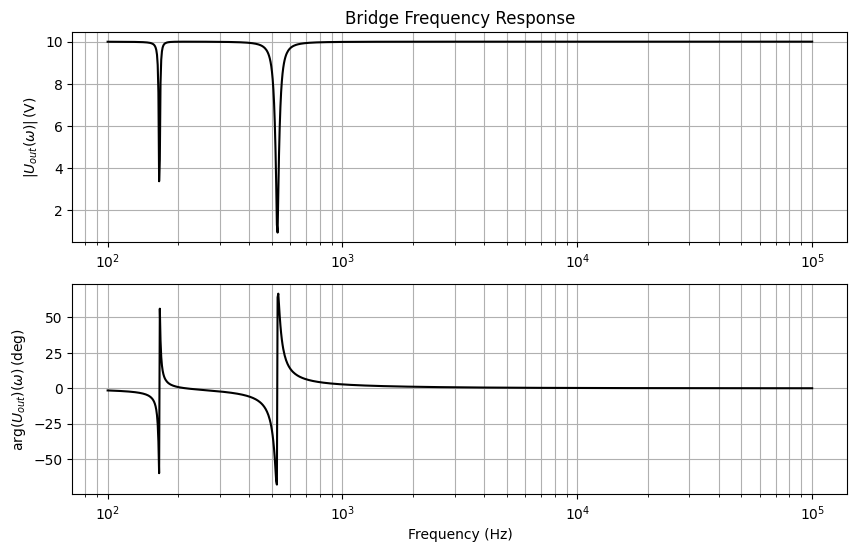

In [9]:
# Experiment 1.1: triangle frequency response:

# Try to build a triangle with A in the floor, B inclined at the left and a C at the right.
topology = [(0, 2), (0, 1), (1, 2)]
struc = Bridge()
struc.construct(lib, topology)

U_arr = np.array([struc.solve_U(w, U_in, R_ref) for w in w_arr]).T
U_out_arr = U_arr[-1,:]
U_mag = np.abs(U_out_arr)
U_phase = np.angle(U_out_arr)

# Plotting:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.semilogx(f_arr, U_mag, color='black')
plt.ylabel(r'$|U_{out}(\omega)|\,(\text{V})$')
plt.grid(True, which="both")
plt.title('Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.semilogx(f_arr, np.degrees(U_phase), color='black')
plt.ylabel(r'$\text{arg}(U_{out})(\omega)\,(\text{deg})$')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

In [10]:
# Experiment 1.2: recover R values for deformed triangle:

# For the next experiment, we will frequency sweep a deformed bridge and try to recover its R vector.
# We will pretend f_arr contains all 500 sweeping frequencies.

# Let's pretend no deformation in A, but elongation in both B and C:
R_deformed = [4700, 1000.0, 2100.0] # 10 % increase for both B and C resistance.

# The measured response (without noise!) should equal:
U_arr_mes = np.array([struc.solve_U(w, U_in, R_ref, R_vec=R_deformed) for w in w_arr]).T
U_out_mes = U_arr_mes[-1,:]

# Let's see what resistances the solver predicts:
R_pred = struc.predict_R(w_arr, U_in, U_out_mes, R_ref, max_iter = 10)
print(R_pred) 





[4693.14256793 1000.24632462 2101.39296951]
